In [12]:
import sys
sys.path.append("..")
import os
import pandas as pd
from tqdm import tqdm
import numpy as np
import re
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [13]:
methods_names = {
    "dist_linguistic_confidence": "Dist. Ling. Conf.",
    "dist_semantic_uncertainty": "Dist. Semantic Unc.",
    "dist_lnll": "Dist. Token Prob"
}

dataset_map = {
    "mmlu": "MMLU",
    "squadv2": "SQuADv2.0",
    "truth_qa": "TruthfulQA"
}

model_name_map = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "Meta-Llama-3-8B-Instruct": "Llama-3-8B-Inst.",
    "Qwen2.5-7B-Instruct": "Qwen2.5-7B-Inst.",
    "Qwen3-8B": "Qwen3-8B-Inst.",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B-Inst.",
    "gpt-oss-20b": "GPT-OSS-20B",
}

In [14]:
results_dir = f"/hdd/ivny/direct_qa_in_domain_calibration"

# list all leaf nodes in results_dir
leaf_dirs = []
for root, dirs, files in os.walk(results_dir):
    if not dirs:  # if there are no subdirectories, it's a leaf node
        leaf_dirs.append(root)

def extract_signal_mean(signal_str):
    # signal_str format: "mu=0.123, sigma=0.456"
    match = re.search(r"mu=([0-9.]+)", str(signal_str))
    if match:
        return float(match.group(1))
    return None

estimators = {
    "lc": {
        "signal_col": "calibrated_lc",
        "rewritten_lc_col": "calibrated_lc_rewritten_lc",
        "rewritten_response_col": "calibrated_lc_rewritten_response",
    },
    "tp": {
        "signal_col": "calibrated_tp",
        "rewritten_lc_col": "calibrated_tp_rewritten_lc",
        "rewritten_response_col": "calibrated_tp_rewritten_response",
    },
    "su": {
        "signal_col": "calibrated_su",
        "rewritten_lc_col": "calibrated_su_rewritten_lc",
        "rewritten_response_col": "calibrated_su_rewritten_response",
    },
}

estimator_label_map = {
    "lc": "Linguistic Confidence",
    "tp": "Token Probability",
    "su": "Semantic Uncertainty",
}

estimator_data = {
    key: {
        "signal_means": [],
        "lc_means": [],
        "original_response": [],
        "calibrated_response": [],
    }
    for key in estimators
}

for leaf_dir in leaf_dirs:
    _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
    calibration_path = os.path.join(leaf_dir, "calibration_details.csv")

    if not os.path.exists(calibration_path):
        print(dataset_name, model_name, "calibration_details.csv not found")
        continue

    csv_data = pd.read_csv(calibration_path, index_col=0)

    for est_key, est_cfg in estimators.items():
        estimator_data[est_key]["original_response"] += csv_data["original_response"].astype(str).tolist()
        estimator_data[est_key]["calibrated_response"] += csv_data[est_cfg["rewritten_response_col"]].astype(str).tolist()
        estimator_data[est_key]["signal_means"] += csv_data[est_cfg["signal_col"]].apply(extract_signal_mean).tolist()
        estimator_data[est_key]["lc_means"] += csv_data[est_cfg["rewritten_lc_col"]].apply(extract_signal_mean).tolist()

# Optional pooled arrays for backward compatibility with downstream cells.
signal_means = []
lc_means = []
original_response = []
calibrated_response = []
for est_key in ["lc", "tp", "su"]:
    signal_means += estimator_data[est_key]["signal_means"]
    lc_means += estimator_data[est_key]["lc_means"]
    original_response += estimator_data[est_key]["original_response"]
    calibrated_response += estimator_data[est_key]["calibrated_response"]

In [15]:
def spearman_with_binning(x, y, n_bins=20, agg='mean'):
    df = pd.DataFrame({'x': x, 'y': y})

    # Create quantile-based bins
    df['bin'] = pd.qcut(df['x'], q=n_bins, duplicates='drop')

    # Aggregate within bins
    if agg == 'mean':
        grouped = df.groupby('bin', observed=True).mean(numeric_only=True)
    elif agg == 'median':
        grouped = df.groupby('bin', observed=True).median(numeric_only=True)
    else:
        raise ValueError("agg must be 'mean' or 'median'")

    # Compute Spearman on aggregated points
    rho, p = spearmanr(grouped['x'], grouped['y'])

    return rho, p, grouped

In [16]:
# Correlation-only setup: one row per estimator (no entailment inference).
def _clean_xy(x_vals, y_vals):
    x_vals = np.asarray(x_vals, dtype=float)
    y_vals = np.asarray(y_vals, dtype=float)
    n = min(len(x_vals), len(y_vals))
    x_vals = x_vals[:n]
    y_vals = y_vals[:n]
    mask = np.isfinite(x_vals) & np.isfinite(y_vals)
    return x_vals[mask], y_vals[mask]

row_order = ["lc", "tp", "su"]

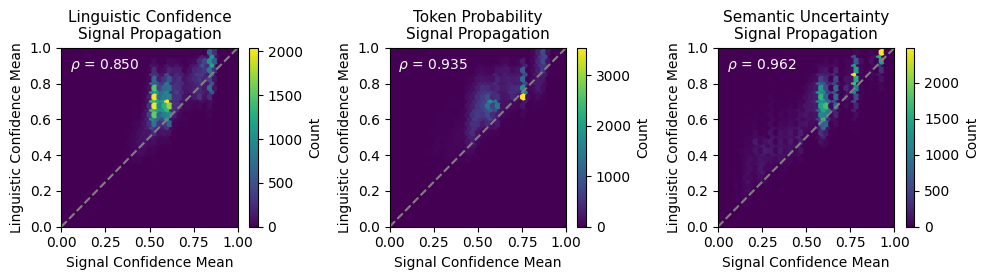

In [33]:
# Build correlation-only figure (1 row x 3 columns).
fig, axes = plt.subplots(1, 3, figsize=(10, 2.9), squeeze=False)

for col_idx, est_key in enumerate(row_order):
    est_label = estimator_label_map.get(est_key, est_key.upper())
    data = estimator_data[est_key]

    x_est, y_est = _clean_xy(data["signal_means"], data["lc_means"])
    # rho_est = spearmanr(x_est, y_est).correlation
    rho_est, _, _ = spearman_with_binning(x_est, y_est, n_bins=3000)

    ax = axes[0, col_idx]
    hb = ax.hexbin(
        x_est,
        y_est,
        gridsize=35,
        extent=(0, 1, 0, 1),
    )
    ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Signal Confidence Mean")
    ax.set_ylabel("Linguistic Confidence Mean")
    ax.set_title(f"{est_label}\nSignal Propagation", fontsize=11)
    ax.text(
        0.05,
        0.95,
        fr"$\rho$ = {rho_est:.3f}",
        transform=ax.transAxes,
        va="top",
        color="white",
    )
    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Count")

plt.tight_layout()
plt.savefig("figs/signal_linguistic_confidence_propagation.pdf", dpi=300, bbox_inches="tight")
plt.show()